In [1]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.drop(columns='transaction_id', inplace=True)

In [4]:
df.isnull().sum()

,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [5]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [6]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [7]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [8]:
import numpy as np

df['hour_sin'] = np.sin (2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos (2 * np.pi * df['transaction_hour']/24)

In [9]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [12]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data training adalah : {len(X_train)} dan jumlah data uji adalah : {len(X_test)}")

Jumlah data training adalah : 8000 dan jumlah data uji adalah : 2000


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [15]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder='passthrough')

In [16]:
from lightgbm import LGBMClassifier

baseline_lgbm = LGBMClassifier(
    random_state=42
)

**Model Baseline**

In [17]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_lgbm)
])

In [18]:
baseline_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 121, number of negative: 7879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015125 -> initscore=-4.176166
[LightGBM] [Info] Start training from score -4.176166
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', LGBMClassifier(random_state=42))])

In [19]:
y_pred_baseline = baseline_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, classification_report

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f'Akurasi model baseline adalah : {accuracy_baseline:.4f}')
print(f'Precision model baseline adalah : {precision_baseline:.4f}')
print(f'Recall model baseline adalah : {recall_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline))

Akurasi model baseline adalah : 1.0000
Precision model baseline adalah : 1.0000
Recall model baseline adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [21]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [22]:
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f'ROC AUC model baseline adalah : {roc_auc_baseline:.4f}')

ROC AUC model baseline adalah : 1.0000


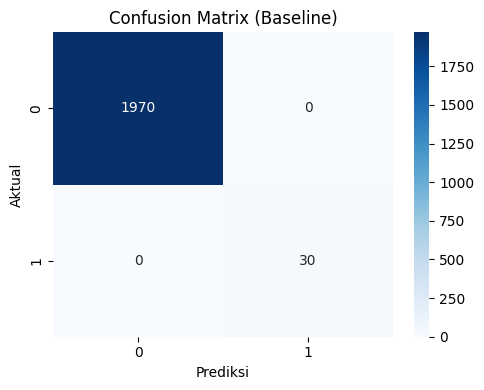

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Balanced**

In [24]:
balanced_lgbm = LGBMClassifier(
    random_state=42,
    class_weight='balanced'
)

In [25]:
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', balanced_lgbm)
])

In [26]:
balanced_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 121, number of negative: 7879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', random_state=42))])

In [27]:
y_pred_balanced = balanced_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
print(f'Akurasi model balanced adalah : {accuracy_balanced:.4f}')
print(f'Precision model balanced adalah : {precision_balanced:.4f}')
print(f'Recall model balanced adalah : {recall_balanced:.4f}')
print(classification_report(y_test, y_pred_balanced))

Akurasi model balanced adalah : 0.9990
Precision model balanced adalah : 0.9375
Recall model balanced adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.94      1.00      0.97        30

    accuracy                           1.00      2000
   macro avg       0.97      1.00      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [29]:
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [30]:
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)
print(f'ROC AUC model balanced adalah : {roc_auc_balanced:.4f}')

ROC AUC model balanced adalah : 1.0000


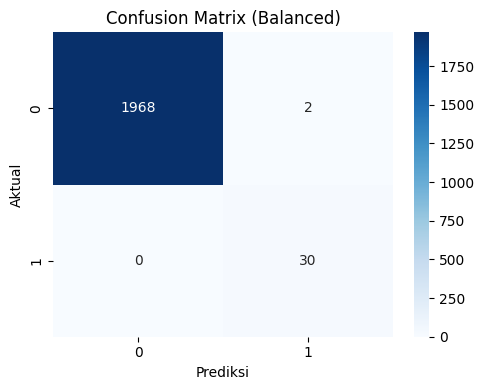

In [31]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Balanced)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model SMOTE**

In [32]:
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = imbPipeline([
    ('preprocessor', preprocessor),
    ('SMOTE', SMOTE(random_state=42)),
    ('model', baseline_lgbm)
])

In [33]:
smote_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 7879, number of negative: 7879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 15758, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('SMOTE', SMOTE(random_state=42)),
                ('model', LGBMClassifier(random_state=42))])

In [34]:
y_pred_smote = smote_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi model SMOTE adalah : {accuracy_smote:.4f}')
print(f'Precision model SMOTE adalah : {precision_smote:.4f}')
print(f'Recall model SMOTE adalah : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi model SMOTE adalah : 0.9990
Precision model SMOTE adalah : 0.9375
Recall model SMOTE adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.94      1.00      0.97        30

    accuracy                           1.00      2000
   macro avg       0.97      1.00      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [36]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f'RPC AUC score model SMOTE : {roc_auc_smote:.4f}')

RPC AUC score model SMOTE : 1.0000


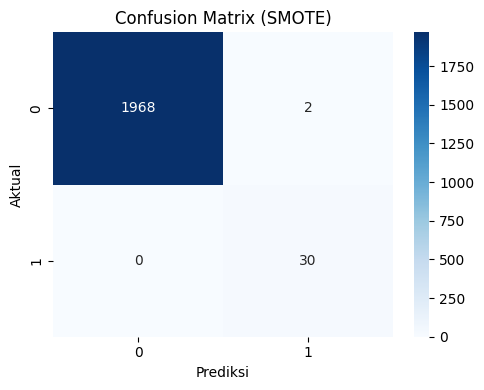

In [38]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Hyperparameter Tuning dengan baseline**

In [39]:
params_grid = {
    'model__n_estimators' : [100, 150, 200],
    'model__learning_rate' : [0.01, 0.05, 0.1],
    'model__max_depth' : [-1, 3, 5, 7, 10],
    'model__num_leaves' : [31, 50, 70],
    'model__min_child_samples' : [10,20,30],
    'model__subsample' : [0.8, 1],
    'model__colsample_bytree' : [0.8, 1]
}

In [40]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = baseline_pipeline,
    param_grid = params_grid,
    scoring = 'f1',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

In [41]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
[LightGBM] [Info] Number of positive: 121, number of negative: 7879
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015125 -> initscore=-4.176166
[LightGBM] [Info] Start training from score -4.176166
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('model',
                                        LGBMClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [-1, 3, 5, 7, 10],
                         'model__min_child_samples': [10, 20, 30],
                         'model__n_estimators': [100, 150, 200],
                         'model__num_leaves': [31, 50, 70],
                         'model__subsample': [0.8, 1]},
             scoring='f1', verbose=1)

In [42]:
print(grid_search.best_params_)

{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_samples': 10, 'model__n_estimators': 200, 'model__num_leaves': 31, 'model__subsample': 0.8}


In [43]:
best_lgbm = grid_search.best_estimator_

In [44]:
y_pred = best_lgbm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi model adalah : {accuracy:.4f}')
print(f'Precision model adalah : {precision:.4f}')
print(f'Recall model adalah : {recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi model adalah : 1.0000
Precision model adalah : 1.0000
Recall model adalah : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [46]:
y_prob = best_lgbm.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [47]:
roc_auc = roc_auc_score(y_test, y_pred)
print(f'ROC AUC score adalah : {roc_auc:.4f}')

ROC AUC score adalah : 1.0000


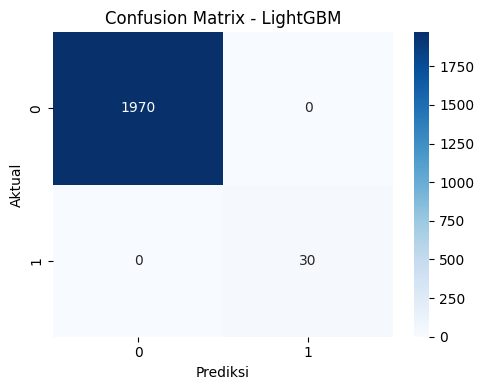

In [48]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [49]:
features_names = X.columns

importance = pd.DataFrame({
    'Feature' : features_names,
    'Importance' : best_lgbm.named_steps['model'].feature_importances_
})

In [50]:
importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

In [51]:
print(importance)

               Feature  Importance
1             hour_sin         271
6    velocity_last_24h         217
2             hour_cos         212
7       cardholder_age         210
5   device_trust_score         196
4    location_mismatch         153
0               amount         125
3  foreign_transaction          13


/tmp/ipykernel_1026/21957892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


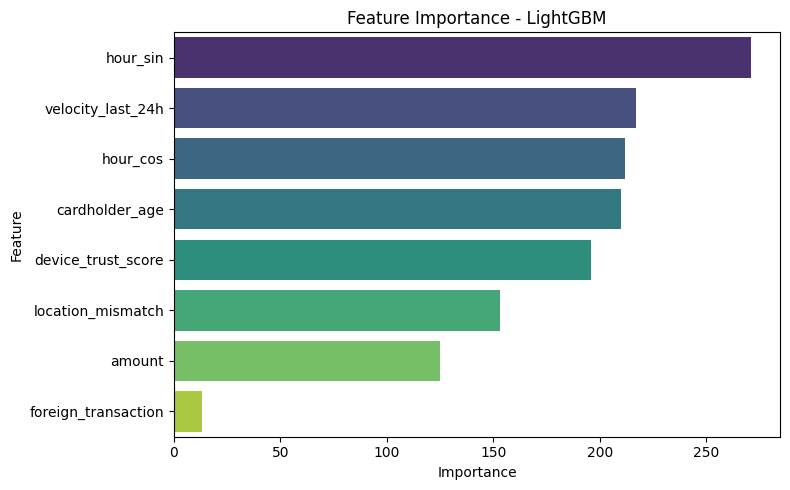

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x= 'Importance',
    y= 'Feature',
    palette='viridis'
)
plt.title('Feature Importance - LightGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [54]:
from google.colab import files
import joblib

joblib.dump(best_lgbm, 'LightGBM_Model.joblib')
files.download('LightGBM_Model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>